## Imports

In [14]:
import os
import io
import zipfile
import urllib.request
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import cv2
from sklearn.manifold import TSNE

torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.benchmark = True

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Device: {device}")

IMG_SIZE = 224
N_CLASSES = 5  # APTOS severity grades 0-4
BATCH_SIZE = 128
NUM_WORKERS = 4
APTOS_DIR = "data/aptos2019"

Device: cuda


## Dataset Preparation

In [15]:
# Dataset used download link - https://www.kaggle.com/datasets/mariaherrerot/aptos2019

train_csv = os.path.join(APTOS_DIR, "train.csv")
val_csv = os.path.join(APTOS_DIR, "val.csv")
test_csv = os.path.join(APTOS_DIR, "test.csv")

if os.path.exists(train_csv):
    df_train = pd.read_csv(train_csv)
    print(f"Loaded {len(df_train)} training labels from {train_csv}")
    print("Class distribution:", df_train['diagnosis'].value_counts().sort_index().to_dict())
else:
    raise FileNotFoundError(f"{train_csv} not found!")

if os.path.exists(val_csv):
    df_val = pd.read_csv(val_csv)
    print(f"Loaded {len(df_train)} training labels from {val_csv}")
    print("Class distribution:", df_val['diagnosis'].value_counts().sort_index().to_dict())
else:
    raise FileNotFoundError(f"{val_csv} not found!")

if os.path.exists(test_csv):
    df_test = pd.read_csv(test_csv)
    print(f"Loaded {len(df_test)} test labels from {test_csv}")
else:
    print(f"WARNING: {test_csv} not found!")
    df_test = pd.DataFrame(columns=['id_code'])

train_img_dir = os.path.join(APTOS_DIR, "train_images")
val_img_dir = os.path.join(APTOS_DIR, "val_images")
test_img_dir = os.path.join(APTOS_DIR, "test_images")
print(f"Train images dir exists: {os.path.exists(train_img_dir)}")
print(f"Val images dir exists: {os.path.exists(val_img_dir)}")
print(f"Test images dir exists: {os.path.exists(test_img_dir)}")

Loaded 2930 training labels from data/aptos2019\train.csv
Class distribution: {0: 1434, 1: 300, 2: 808, 3: 154, 4: 234}
Loaded 2930 training labels from data/aptos2019\val.csv
Class distribution: {0: 172, 1: 40, 2: 104, 3: 22, 4: 28}
Loaded 366 test labels from data/aptos2019\test.csv
Train images dir exists: True
Val images dir exists: True
Test images dir exists: True


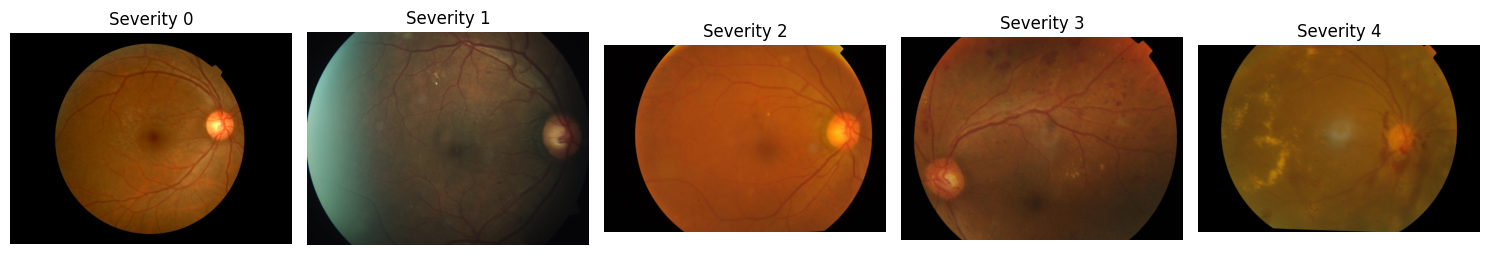

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for sev, ax in enumerate(axes):
    idx = df_train[df_train['diagnosis'] == sev].index[0]
    fname = df_train.loc[idx, 'id_code'] + ".png"
    fpath = os.path.join(train_img_dir, fname)
    img = Image.open(fpath).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Severity {sev}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [17]:
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['id_code'] + ".png"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = row['diagnosis']

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = APTOSDataset(df_train, train_img_dir, transform=train_transform)
val_dataset = APTOSDataset(df_val, val_img_dir, transform=val_test_transform)
test_dataset = APTOSDataset(df_test, test_img_dir, transform=val_test_transform)

images, labels = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=True)))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")
print(f"Label range: {labels.min()} - {labels.max()}")

Batch shape: torch.Size([4, 3, 224, 224]), Labels shape: torch.Size([4])
Label range: 0 - 2


In [19]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

## Model Definition
We use MobileNetV2 as backbone with custom classifier head

In [20]:
def create_model(num_classes=N_CLASSES, pretrained=True, freeze_backbone=True):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

    return model

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model = create_model(freeze_backbone=True).to(device)
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

print("\nModel architecture:")
print(model)

Total parameters: 2,882,309
Trainable parameters: 658,437
Frozen parameters: 2,223,872

Model architecture:
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
    

## Training Setup

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_score, model):
        if self.best_score is None:
            self.best_score = val_score
            self.best_model_state = model.state_dict().copy()
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0
            self.best_model_state = model.state_dict().copy()

early_stopping = EarlyStopping(patience=7, min_delta=0.001)

In [22]:
# Training functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=True)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        current_acc = 100. * correct / total
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Validation', leave=True)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_acc = 100. * correct / total
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

# Test training step
print("Testing training step...")
train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Testing training step...


Validation: 100%|██████████| 3/3 [00:33<00:00, 11.12s/it, loss=0.7609, acc=72.68%]

Train Loss: 0.9892, Train Acc: 65.87%
Val Loss: 0.7587, Val Acc: 72.68%


## Progressive Unfreezing Training

We'll train in stages:
1. Stage 1: Train only classifier head (backbone frozen)
2. Stage 2: Unfreeze last few layers of backbone
3. Stage 3: Unfreeze more layers with lower learning rate
4. Stage 4: Full fine-tuning with very low learning rate

In [23]:
def unfreeze_layers(model, num_layers_to_unfreeze):
    # MobileNetV2 features has 18 layers (0-17)
    features = list(model.features.children())
    total_layers = len(features)

    for param in model.features.parameters():
        param.requires_grad = False

    for i in range(max(0, total_layers - num_layers_to_unfreeze), total_layers):
        for param in features[i].parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Unfroze last {num_layers_to_unfreeze} layers. Trainable: {trainable:,} / {total:,}")


def train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, epochs, stage_name, early_stopping=None):

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in tqdm(range(epochs), desc=f"Stage: {stage_name}", unit="epoch"):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(val_acc)

        tqdm.write(f"Epoch {epoch+1}/{epochs} | "
                   f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                   f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
                   f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if early_stopping:
            early_stopping(val_acc, model)
            if early_stopping.early_stop:
                tqdm.write(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(early_stopping.best_model_state)
                break

    return history

In [24]:
print("Stage 1: Training classifier head only...")
model = create_model(freeze_backbone=True).to(device)
total_params, trainable_params = count_parameters(model)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history1 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 1: Classifier Only",
                       early_stopping=early_stopping)


Stage 1: Training classifier head only...
Trainable parameters: 658,437 / 2,882,309


Stage: Stage 1: Classifier Only:   7%|▋         | 1/15 [04:47<1:07:01, 287.22s/epoch]

Epoch 1/15 | Train Loss: 1.0477, Train Acc: 62.42% | Val Loss: 0.7678, Val Acc: 72.13% | LR: 1.00e-03


Stage: Stage 1: Classifier Only:  13%|█▎        | 2/15 [12:22<1:23:39, 386.14s/epoch]

Epoch 2/15 | Train Loss: 0.7238, Train Acc: 72.66% | Val Loss: 0.7232, Val Acc: 73.50% | LR: 1.00e-03


...

Epoch 13/15 | Train Loss: 0.5203, Train Acc: 80.24% | Val Loss: 0.5983, Val Acc: 79.23% | LR: 5.00e-04


Stage: Stage 1: Classifier Only:  93%|█████████▎| 14/15 [2:22:23<09:21, 561.22s/epoch]

Epoch 14/15 | Train Loss: 0.5362, Train Acc: 79.39% | Val Loss: 0.5954, Val Acc: 78.14% | LR: 5.00e-04


Stage: Stage 1: Classifier Only: 100%|██████████| 15/15 [2:28:35<00:00, 594.35s/epoch]

Epoch 15/15 | Train Loss: 0.5179, Train Acc: 80.34% | Val Loss: 0.5830, Val Acc: 79.23% | LR: 5.00e-04


In [25]:
print("Stage 2: Unfreezing last 4 layers...")
unfreeze_layers(model, 4)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history2 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 2: Last 4 Layers",
                       early_stopping=early_stopping)

Stage 2: Unfreezing last 4 layers...
Unfroze last 4 layers. Trainable: 2,184,517 / 2,882,309


Stage: Stage 2: Last 4 Layers:   7%|▋         | 1/15 [06:17<1:28:11, 377.94s/epoch]

Epoch 1/15 | Train Loss: 0.6425, Train Acc: 76.31% | Val Loss: 0.6265, Val Acc: 78.14% | LR: 5.00e-04


Stage: Stage 2: Last 4 Layers:  13%|█▎        | 2/15 [15:41<1:45:32, 487.10s/epoch]

Epoch 2/15 | Train Loss: 0.4736, Train Acc: 82.32% | Val Loss: 0.5947, Val Acc: 79.78% | LR: 5.00e-04


...

Epoch 13/15 | Train Loss: 0.1790, Train Acc: 92.94% | Val Loss: 0.7607, Val Acc: 79.23% | LR: 5.00e-04


Stage: Stage 2: Last 4 Layers:  93%|█████████▎| 14/15 [1:15:57<04:53, 293.99s/epoch]

Epoch 14/15 | Train Loss: 0.1846, Train Acc: 93.38% | Val Loss: 0.6370, Val Acc: 81.42% | LR: 2.50e-04


Stage: Stage 2: Last 4 Layers: 100%|██████████| 15/15 [1:20:47<00:00, 323.17s/epoch]

Epoch 15/15 | Train Loss: 0.1341, Train Acc: 95.12% | Val Loss: 0.6661, Val Acc: 81.97% | LR: 2.50e-04


In [26]:
print("Stage 3: Unfreezing last 8 layers...")
unfreeze_layers(model, 8)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history3 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 3: Last 8 Layers",
                       early_stopping=early_stopping)

Stage 3: Unfreezing last 8 layers...
Unfroze last 8 layers. Trainable: 2,642,949 / 2,882,309


Stage: Stage 3: Last 8 Layers:   7%|▋         | 1/15 [04:59<1:09:50, 299.33s/epoch]

Epoch 1/15 | Train Loss: 0.1158, Train Acc: 96.35% | Val Loss: 0.7116, Val Acc: 82.24% | LR: 1.00e-04


Stage: Stage 3: Last 8 Layers:  13%|█▎        | 2/15 [09:54<1:04:18, 296.80s/epoch]

Epoch 2/15 | Train Loss: 0.0925, Train Acc: 96.59% | Val Loss: 0.7379, Val Acc: 81.42% | LR: 1.00e-04


...

Epoch 13/15 | Train Loss: 0.0364, Train Acc: 98.84% | Val Loss: 0.8189, Val Acc: 83.33% | LR: 5.00e-05


Stage: Stage 3: Last 8 Layers:  93%|█████████▎| 14/15 [1:08:41<04:54, 294.87s/epoch]

Epoch 14/15 | Train Loss: 0.0382, Train Acc: 98.33% | Val Loss: 0.8224, Val Acc: 82.51% | LR: 5.00e-05


Stage: Stage 3: Last 8 Layers: 100%|██████████| 15/15 [1:13:33<00:00, 294.27s/epoch]

Epoch 15/15 | Train Loss: 0.0429, Train Acc: 98.50% | Val Loss: 0.8321, Val Acc: 83.33% | LR: 5.00e-05


In [27]:
print("Stage 4: Full fine-tuning...")
for param in model.parameters():
    param.requires_grad = True
total_params, trainable_params = count_parameters(model)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=10, min_delta=0.001)

history4 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=20, stage_name="Stage 4: Full Fine-tuning",
                       early_stopping=early_stopping)

Stage 4: Full fine-tuning...
Trainable parameters: 2,882,309 / 2,882,309


Stage: Stage 4: Full Fine-tuning:   5%|▌         | 1/20 [07:14<2:17:28, 434.13s/epoch]

Epoch 1/20 | Train Loss: 0.0448, Train Acc: 98.43% | Val Loss: 0.8587, Val Acc: 82.79% | LR: 5.00e-05


Stage: Stage 4: Full Fine-tuning:  10%|█         | 2/20 [14:36<2:11:36, 438.70s/epoch]

Epoch 2/20 | Train Loss: 0.0432, Train Acc: 98.81% | Val Loss: 0.8489, Val Acc: 83.06% | LR: 5.00e-05


...

Epoch 18/20 | Train Loss: 0.0276, Train Acc: 98.81% | Val Loss: 0.9006, Val Acc: 83.61% | LR: 2.50e-05


Stage: Stage 4: Full Fine-tuning:  95%|█████████▌| 19/20 [2:22:40<07:34, 454.32s/epoch]

Epoch 19/20 | Train Loss: 0.0313, Train Acc: 98.77% | Val Loss: 0.9188, Val Acc: 84.15% | LR: 1.25e-05


Stage: Stage 4: Full Fine-tuning: 100%|██████████| 20/20 [2:30:25<00:00, 451.27s/epoch]

Epoch 20/20 | Train Loss: 0.0216, Train Acc: 99.15% | Val Loss: 0.9348, Val Acc: 84.15% | LR: 1.25e-05


In [28]:
full_history = {
    'train_loss': history1['train_loss'] + history2['train_loss'] + history3['train_loss'] + history4['train_loss'],
    'train_acc': history1['train_acc'] + history2['train_acc'] + history3['train_acc'] + history4['train_acc'],
    'val_loss': history1['val_loss'] + history2['val_loss'] + history3['val_loss'] + history4['val_loss'],
    'val_acc': history1['val_acc'] + history2['val_acc'] + history3['val_acc'] + history4['val_acc'],
}

# Save best model
torch.save(model.state_dict(), "mobilenetv2_aptos_best.pth")
print("\nBest model saved to mobilenetv2_aptos_best.pth")


Best model saved to mobilenetv2_aptos_best.pth


## Plotting

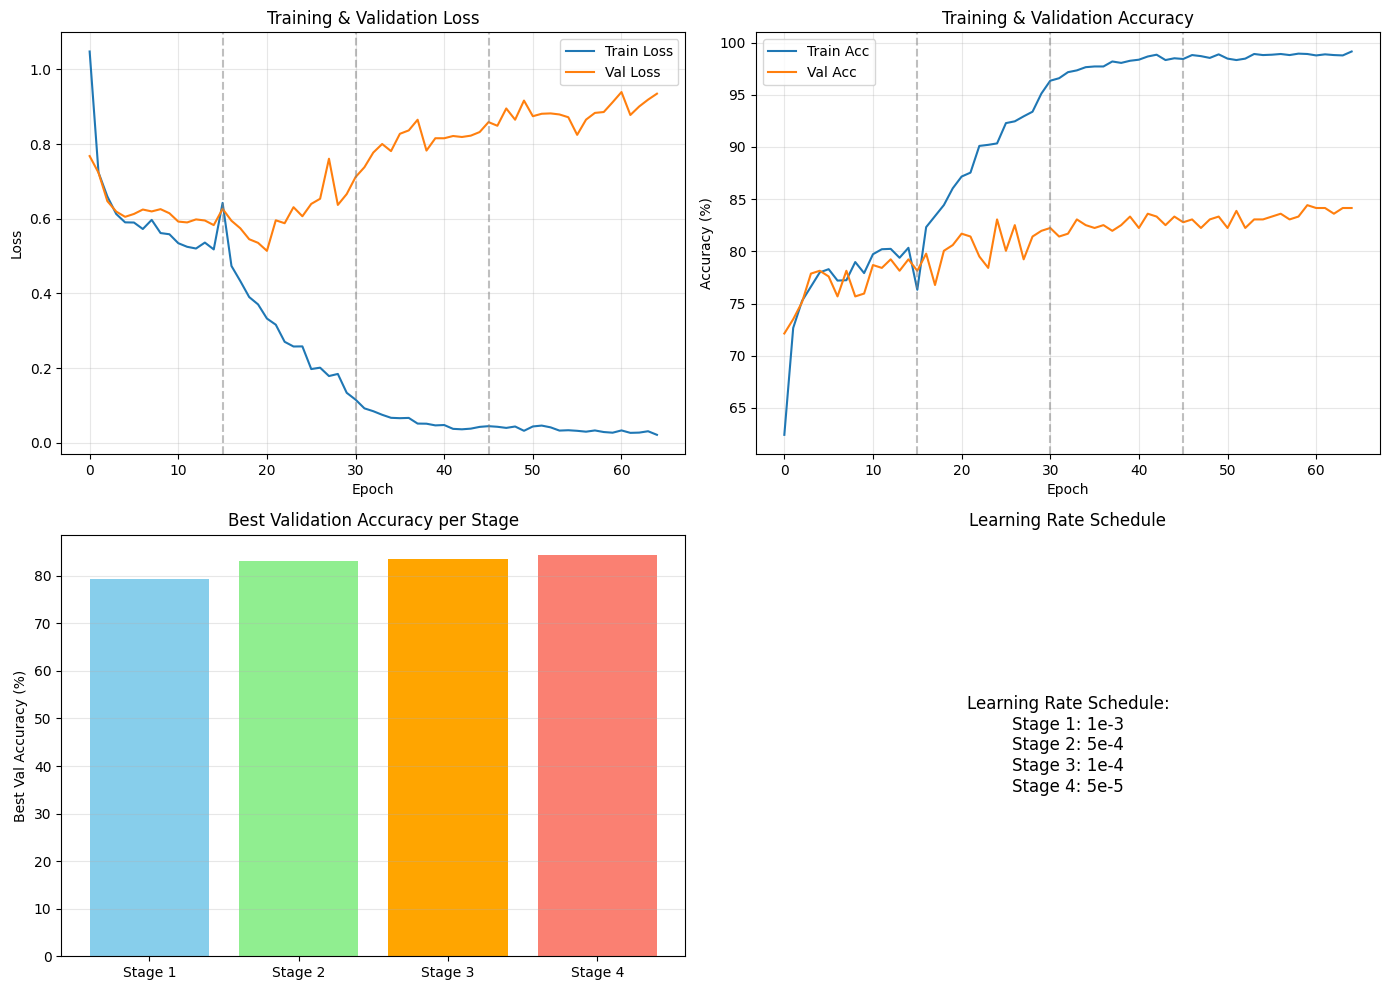

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stage_boundaries = [
    len(history1['train_loss']),
    len(history1['train_loss']) + len(history2['train_loss']),
    len(history1['train_loss']) + len(history2['train_loss']) + len(history3['train_loss']),
]
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

axes[0, 0].plot(full_history['train_loss'], label='Train Loss')
axes[0, 0].plot(full_history['val_loss'], label='Val Loss')
for b in stage_boundaries:
    axes[0, 0].axvline(x=b, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(full_history['train_acc'], label='Train Acc')
axes[0, 1].plot(full_history['val_acc'], label='Val Acc')
for b in stage_boundaries:
    axes[0, 1].axvline(x=b, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training & Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

stage_val_accs = [
    max(history1['val_acc']),
    max(history2['val_acc']),
    max(history3['val_acc']),
    max(history4['val_acc']),
]
axes[1, 0].bar(stage_names, stage_val_accs, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
axes[1, 0].set_ylabel('Best Val Accuracy (%)')
axes[1, 0].set_title('Best Validation Accuracy per Stage')
axes[1, 0].grid(True, alpha=0.3, axis='y')

lrs = []
for h in [history1, history2, history3, history4]:
    pass
axes[1, 1].text(0.5, 0.5, 'Learning Rate Schedule:\nStage 1: 1e-3\nStage 2: 5e-4\nStage 3: 1e-4\nStage 4: 5e-5',
                ha='center', va='center', fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Model Evaluation

Validation: 100%|██████████| 3/3 [00:39<00:00, 13.08s/it, loss=0.8220, acc=84.15%]


Final Validation Loss: 0.9348
Final Validation Accuracy: 84.15%

Classification Report:
                  precision    recall  f1-score   support

           No DR     0.9771    0.9942    0.9856       172
            Mild     0.7647    0.6500    0.7027        40
        Moderate     0.7317    0.8654    0.7930       104
          Severe     0.6667    0.2727    0.3871        22
Proliferative DR     0.6000    0.5357    0.5660        28

        accuracy                         0.8415       366
       macro avg     0.7480    0.6636    0.6869       366
    weighted avg     0.8367    0.8415    0.8319       366



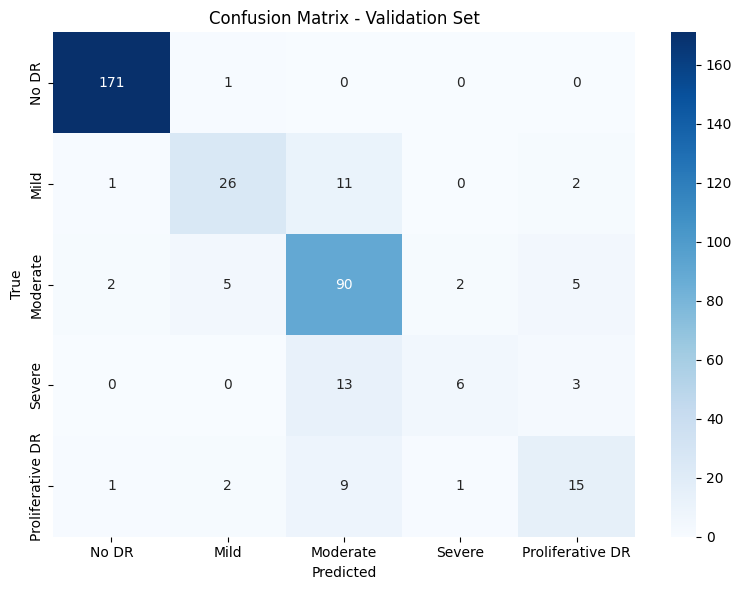


Per-class Accuracy:
  No DR: 99.42% (172 samples)
  Mild: 65.00% (40 samples)
  Moderate: 86.54% (104 samples)
  Severe: 27.27% (22 samples)
  Proliferative DR: 53.57% (28 samples)


In [30]:
model.load_state_dict(torch.load("mobilenetv2_aptos_best.pth", map_location=device))
model.eval()

val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.2f}%")

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

print("\nPer-class Accuracy:")
for i, name in enumerate(class_names):
    class_mask = np.array(val_labels) == i
    if class_mask.sum() > 0:
        class_acc = (np.array(val_preds)[class_mask] == i).mean() * 100
        print(f"  {name}: {class_acc:.2f}% ({class_mask.sum()} samples)")

## Feature Visualisation - Grad-CAM

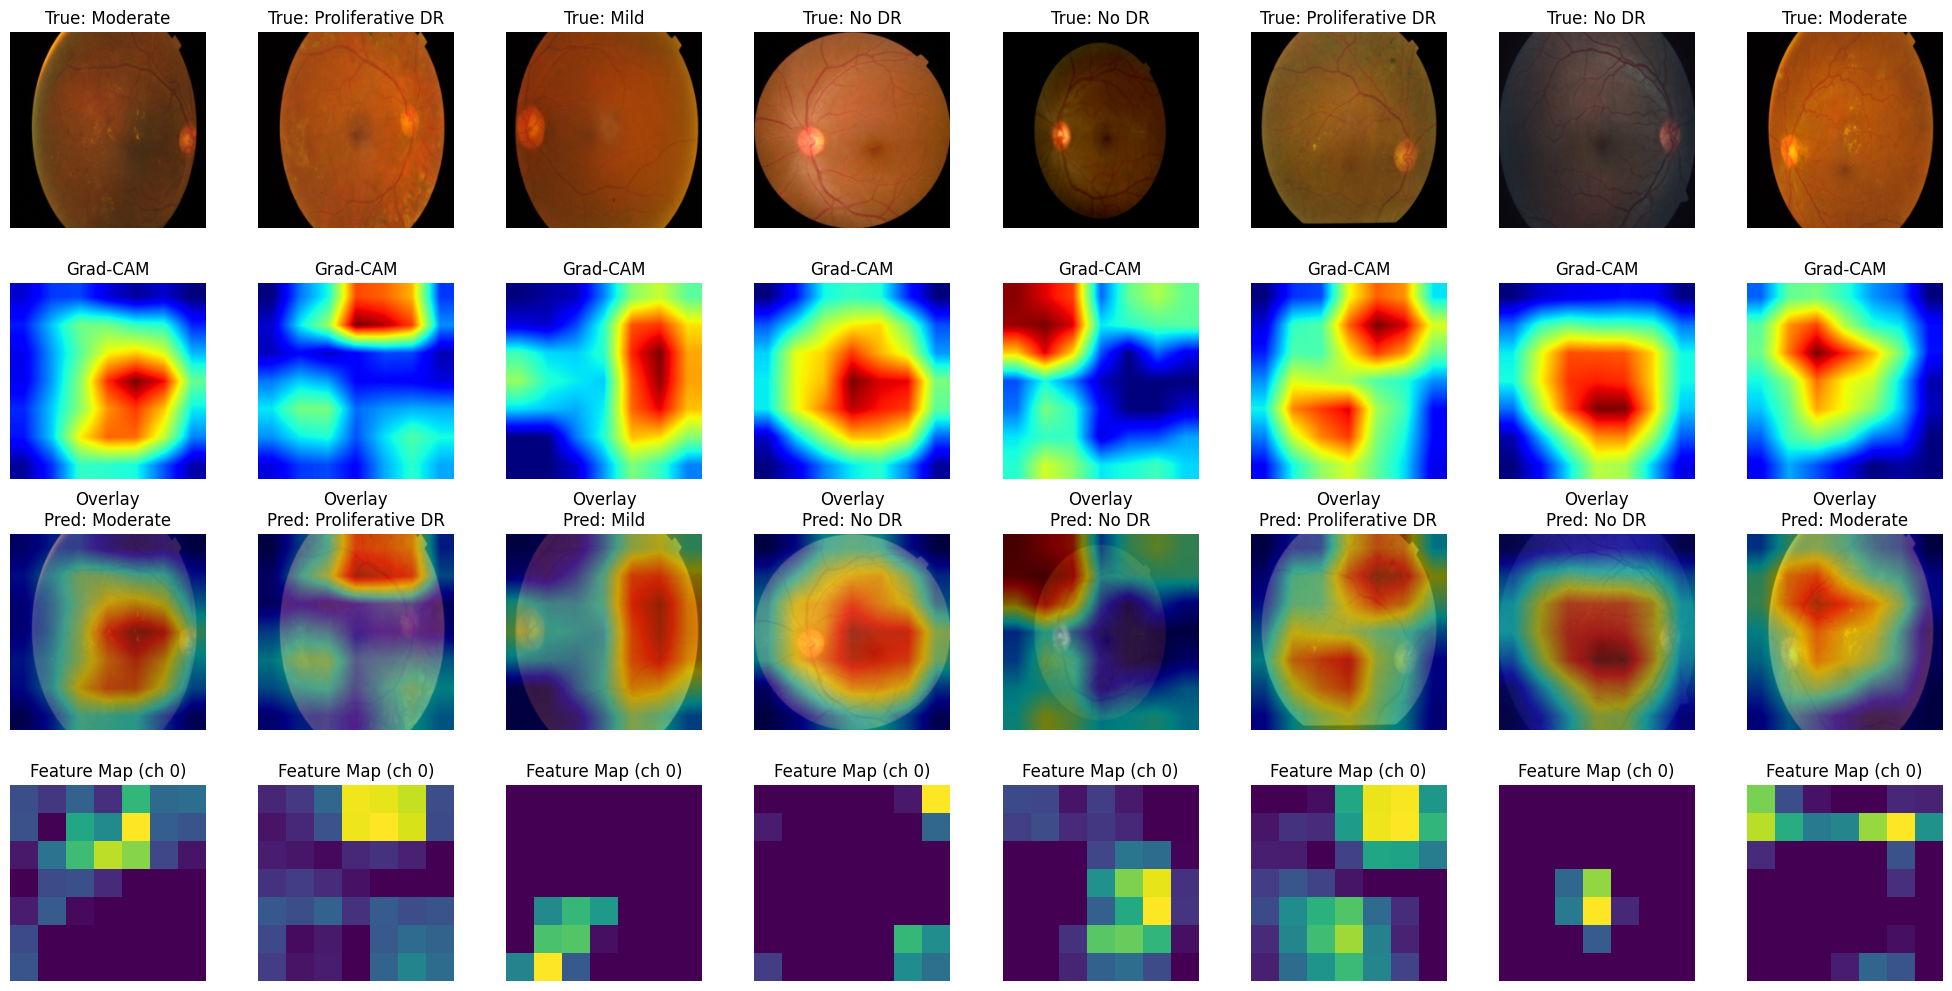

In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        target = output[0, class_idx]
        target.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = (weights[:, None, None] * activations).sum(dim=0)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

target_layer = model.features[-1][0]
gradcam = GradCAM(model, target_layer)

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

val_images, val_labels = next(iter(val_loader))
val_images = val_images[:8].to(device)
val_labels = val_labels[:8]

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i in range(8):
    img = val_images[i:i+1]
    label = val_labels[i].item()

    orig_img = denormalize(img[0].cpu()).permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img, 0, 1)

    cam, pred_idx = gradcam(img)

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * orig_img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f"True: {class_names[label]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_resized, cmap='jet')
    axes[1, i].set_title(f"Grad-CAM")
    axes[1, i].axis('off')

    axes[2, i].imshow(overlay)
    axes[2, i].set_title(f"Overlay\nPred: {class_names[pred_idx]}")
    axes[2, i].axis('off')

    with torch.no_grad():
        features = model.features(img)
    feat_map = features[0, 0].cpu().numpy()
    axes[3, i].imshow(feat_map, cmap='viridis')
    axes[3, i].set_title(f"Feature Map (ch 0)")
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

## Feature Map Visualisation

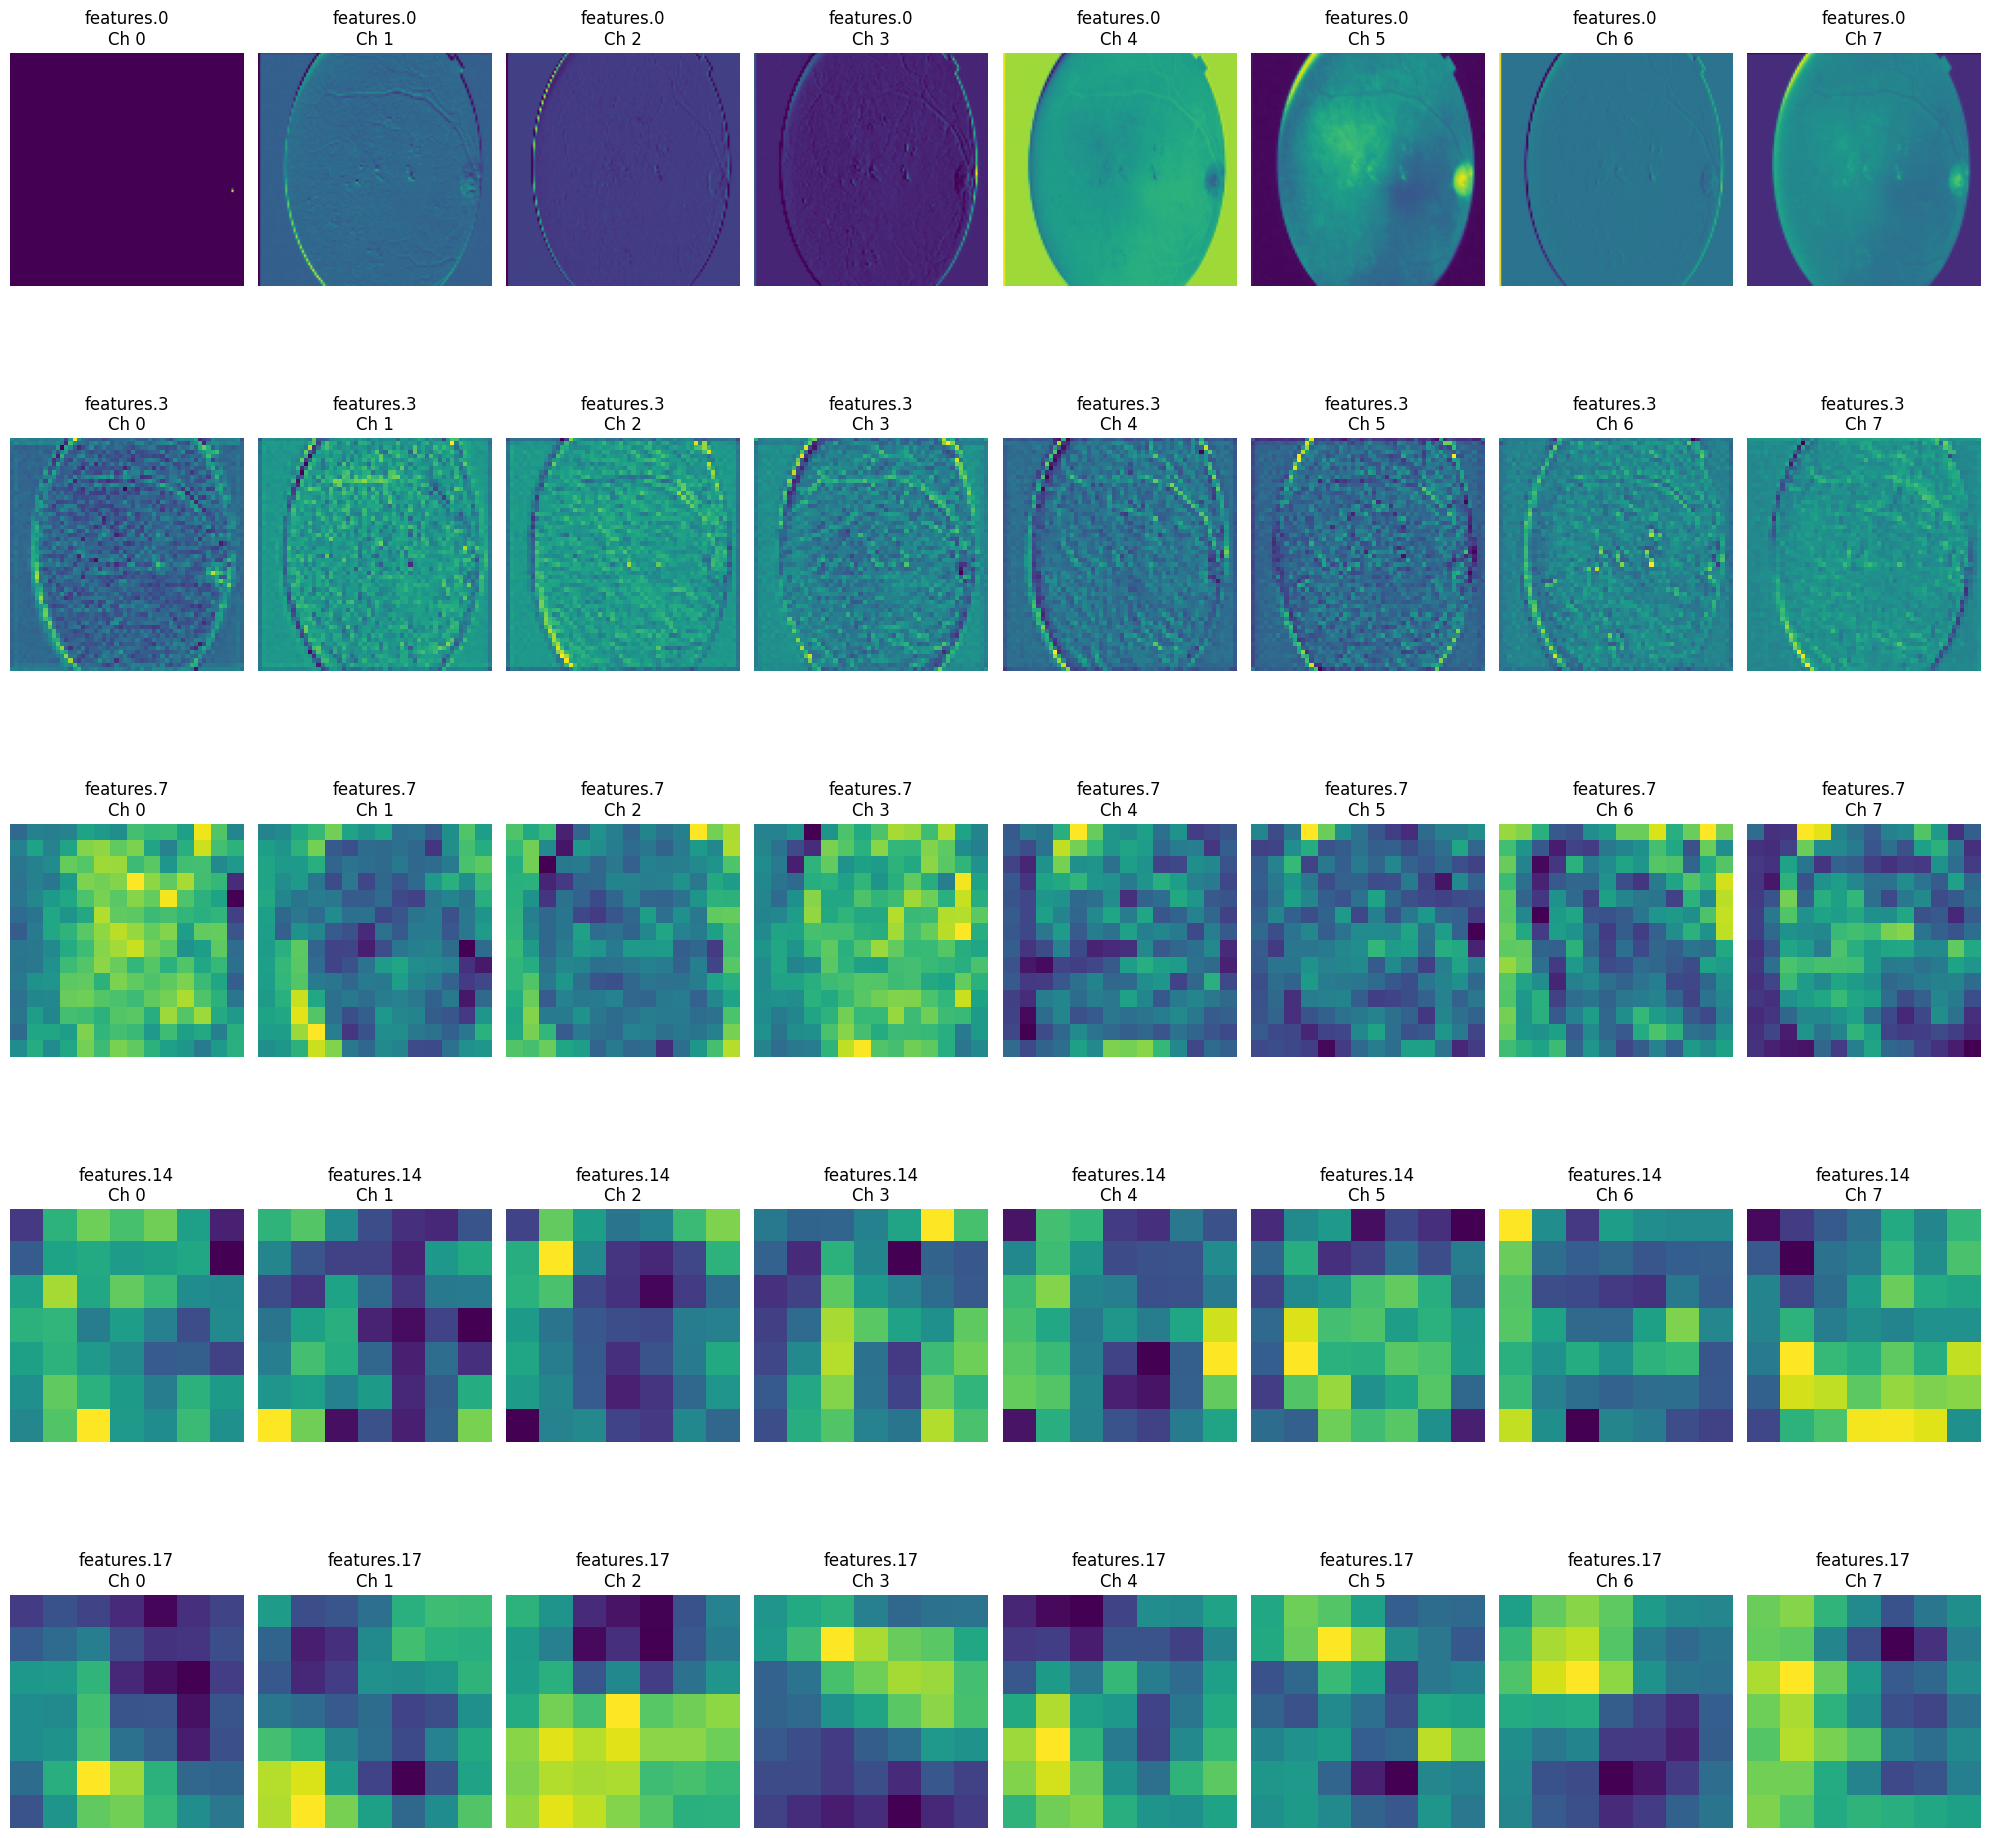

In [32]:
def get_feature_maps(model, x, layer_names):
    feature_maps = {}

    def hook_fn(name):
        def hook(module, input, output):
            feature_maps[name] = output.detach()
        return hook

    hooks = []
    for name in layer_names:
        layer = dict(model.named_modules())[name]
        hooks.append(layer.register_forward_hook(hook_fn(name)))

    with torch.no_grad():
        model(x)

    for h in hooks:
        h.remove()

    return feature_maps

layer_names = [
    'features.0',
    'features.3',
    'features.7',
    'features.14',
    'features.17',
]

sample_img, sample_label = val_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

feature_maps = get_feature_maps(model, sample_img, layer_names)

fig, axes = plt.subplots(len(layer_names), 8, figsize=(20, 4*len(layer_names)))
for row_idx, layer_name in enumerate(layer_names):
    fmaps = feature_maps[layer_name][0]  # (C, H, W)
    n_channels = min(8, fmaps.shape[0])

    for ch in range(n_channels):
        fm = fmaps[ch].cpu().numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[row_idx, ch].imshow(fm, cmap='viridis')
        axes[row_idx, ch].set_title(f"{layer_name}\nCh {ch}")
        axes[row_idx, ch].axis('off')

    for ch in range(n_channels, 8):
        axes[row_idx, ch].axis('off')

plt.tight_layout()
plt.show()

## t-SNE Visualisation of Learned Features

Extracting features for t-SNE...
Features shape: torch.Size([366, 512])
Running t-SNE...


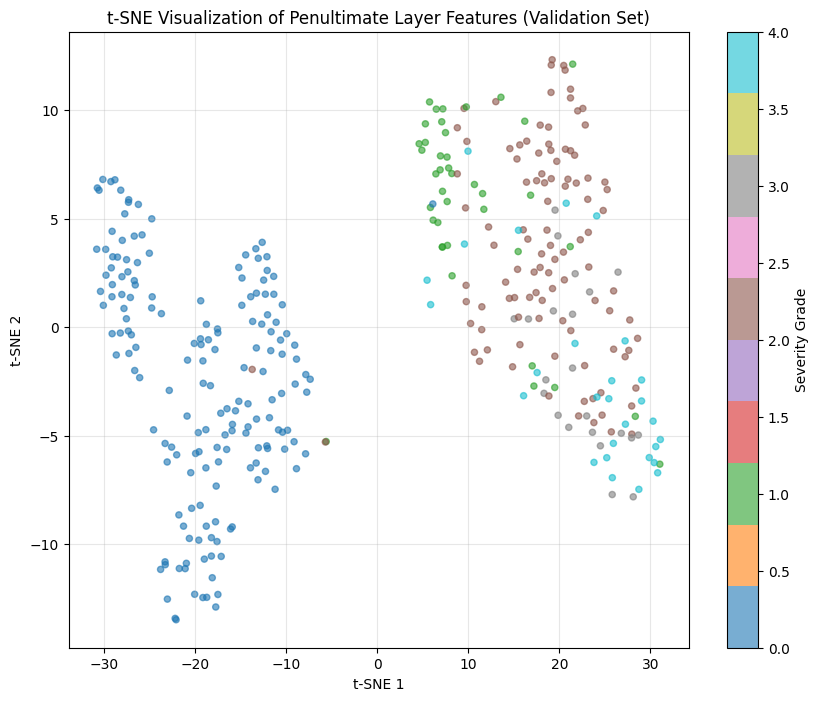

In [34]:
def extract_features(model, loader, device):
    model.eval()
    features = []
    labels = []

    penultimate_features = []
    def hook(module, input, output):
        penultimate_features.append(output.detach())

    handle = model.classifier[1].register_forward_hook(hook)

    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            _ = model(images)
            features.append(penultimate_features[-1].cpu())
            labels.append(lbls)
            penultimate_features.clear()

    handle.remove()
    return torch.cat(features), torch.cat(labels)

print("Extracting features for t-SNE...")
val_features, val_labels_tsne = extract_features(model, val_loader, device)
print(f"Features shape: {val_features.shape}")

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
features_2d = tsne.fit_transform(val_features.numpy())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=val_labels_tsne.numpy(),
                      cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Severity Grade')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization of Penultimate Layer Features (Validation Set)')
plt.grid(True, alpha=0.3)
plt.show()